## Generate UMAP embeddings from no QC data and plot

In [1]:
from pathlib import Path

import pandas as pd
import umap
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_point,
    ggplot,
    guide_legend,
    guides,
    labs,
    scale_color_brewer,
    scale_color_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from pycytominer.cyto_utils import infer_cp_features

In [2]:
# Set constants
umap_random_seed = 0
umap_n_components = 2

# Set output directory
output_dir = Path("./figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Load in no QC normalized dataframe for CFReT example plate
no_QC_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected_no_QC.parquet"
    )
)

# Drop any NaN rows from columns that are not metadata (contain Metadata_ prefix)
no_QC_df = no_QC_df.dropna(
    subset=[col for col in no_QC_df.columns if not col.startswith("Metadata_")]
).reset_index(drop=True)

# Create new column for treatment cell type ID for each unique combo
no_QC_df["Metadata_Treatment_CellType_ID"] = (
    no_QC_df["Metadata_treatment"] + "_" + no_QC_df["Metadata_cell_type"]
)

# Print shape of the DataFrame
print(no_QC_df.shape)
no_QC_df.head()

(25859, 588)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Nuclei_Texture_InverseDifferenceMoment_Actin_3_02_256,Nuclei_Texture_InverseDifferenceMoment_ER_3_01_256,Nuclei_Texture_InverseDifferenceMoment_Mitochondria_3_03_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_01_256,Nuclei_Texture_InverseDifferenceMoment_PM_3_03_256,Nuclei_Texture_SumVariance_ER_3_01_256,Nuclei_Texture_SumVariance_Hoechst_3_01_256,Nuclei_Texture_SumVariance_Mitochondria_3_01_256,Nuclei_Texture_SumVariance_PM_3_01_256,Metadata_Treatment_CellType_ID
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,0.309281,-0.612973,0.906721,0.418794,0.385735,-0.133843,-0.363257,-0.262538,-0.309825,DMSO_failing
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,-0.057546,-0.419084,-0.068447,0.437270,0.335719,-0.216157,-0.371891,2.526579,-0.183663,DMSO_failing
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,-0.206961,-0.620694,0.454668,0.791982,0.541460,-0.121337,-0.395564,-0.234732,-0.316161,DMSO_failing
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,0.638283,-0.408078,0.206056,0.707142,0.398355,-0.164322,-0.366784,-0.150974,-0.212531,DMSO_failing
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,0.061901,0.763259,-0.821989,0.978198,0.974789,-0.433306,-0.391546,0.044598,-0.349236,DMSO_failing


In [3]:
# Process cp_df to separate features and metadata
cp_features = infer_cp_features(no_QC_df)
meta_features = infer_cp_features(no_QC_df, metadata=True)

# Initialize UMAP instance
umap_fit = umap.UMAP(
    random_state=umap_random_seed, n_components=umap_n_components, n_jobs=1
)

# Fit UMAP and convert to pandas DataFrame
embeddings = pd.DataFrame(
    umap_fit.fit_transform(no_QC_df.loc[:, cp_features]),
    columns=[f"UMAP{x}" for x in range(0, umap_n_components)],
)
print(f"{embeddings.shape} UMAP embeddings generated")

# Combine with metadata
cp_umap_with_metadata_df = pd.concat(
    [no_QC_df.loc[:, meta_features], embeddings], axis=1
)

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


(25859, 2) UMAP embeddings generated


In [4]:
print(cp_umap_with_metadata_df.shape)
cp_umap_with_metadata_df.head()

(25859, 22)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_Treatment_CellType_ID,UMAP0,UMAP1
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,localhost230405150001,B02,1,1,6,6,f00,DMSO_failing,-1.922906,4.877175
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,localhost230405150001,B02,2,2,7,7,f00,DMSO_failing,-1.013506,8.063534
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,localhost230405150001,B02,3,3,8,8,f00,DMSO_failing,-1.567515,8.384867
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,localhost230405150001,B02,4,4,9,9,f00,DMSO_failing,-1.829608,5.973942
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,localhost230405150001,B02,5,5,10,10,f00,DMSO_failing,-0.872547,5.672281


In [5]:
# Add QC_status column and set all to "failed"
cp_umap_with_metadata_df["QC_status"] = "failed"

# Find matching rows and set QC_status to "passed"
match_cols = [
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

# Load in no QC normalized dataframe for CFReT example plate
QC_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected.parquet"
    )
)

# Create a MultiIndex for fast lookup
qc_index = QC_df.set_index(match_cols).index
mask = cp_umap_with_metadata_df.set_index(match_cols).index.isin(qc_index)
cp_umap_with_metadata_df.loc[mask, "QC_status"] = "passed"

print(cp_umap_with_metadata_df.shape)
cp_umap_with_metadata_df.head()

(25859, 23)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_Treatment_CellType_ID,UMAP0,UMAP1,QC_status
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,B02,1,1,6,6,f00,DMSO_failing,-1.922906,4.877175,passed
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,B02,2,2,7,7,f00,DMSO_failing,-1.013506,8.063534,passed
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,B02,3,3,8,8,f00,DMSO_failing,-1.567515,8.384867,passed
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,B02,4,4,9,9,f00,DMSO_failing,-1.829608,5.973942,passed
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,B02,5,5,10,10,f00,DMSO_failing,-0.872547,5.672281,passed


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 9 x 8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/facet_umap_no_QC_plot.png


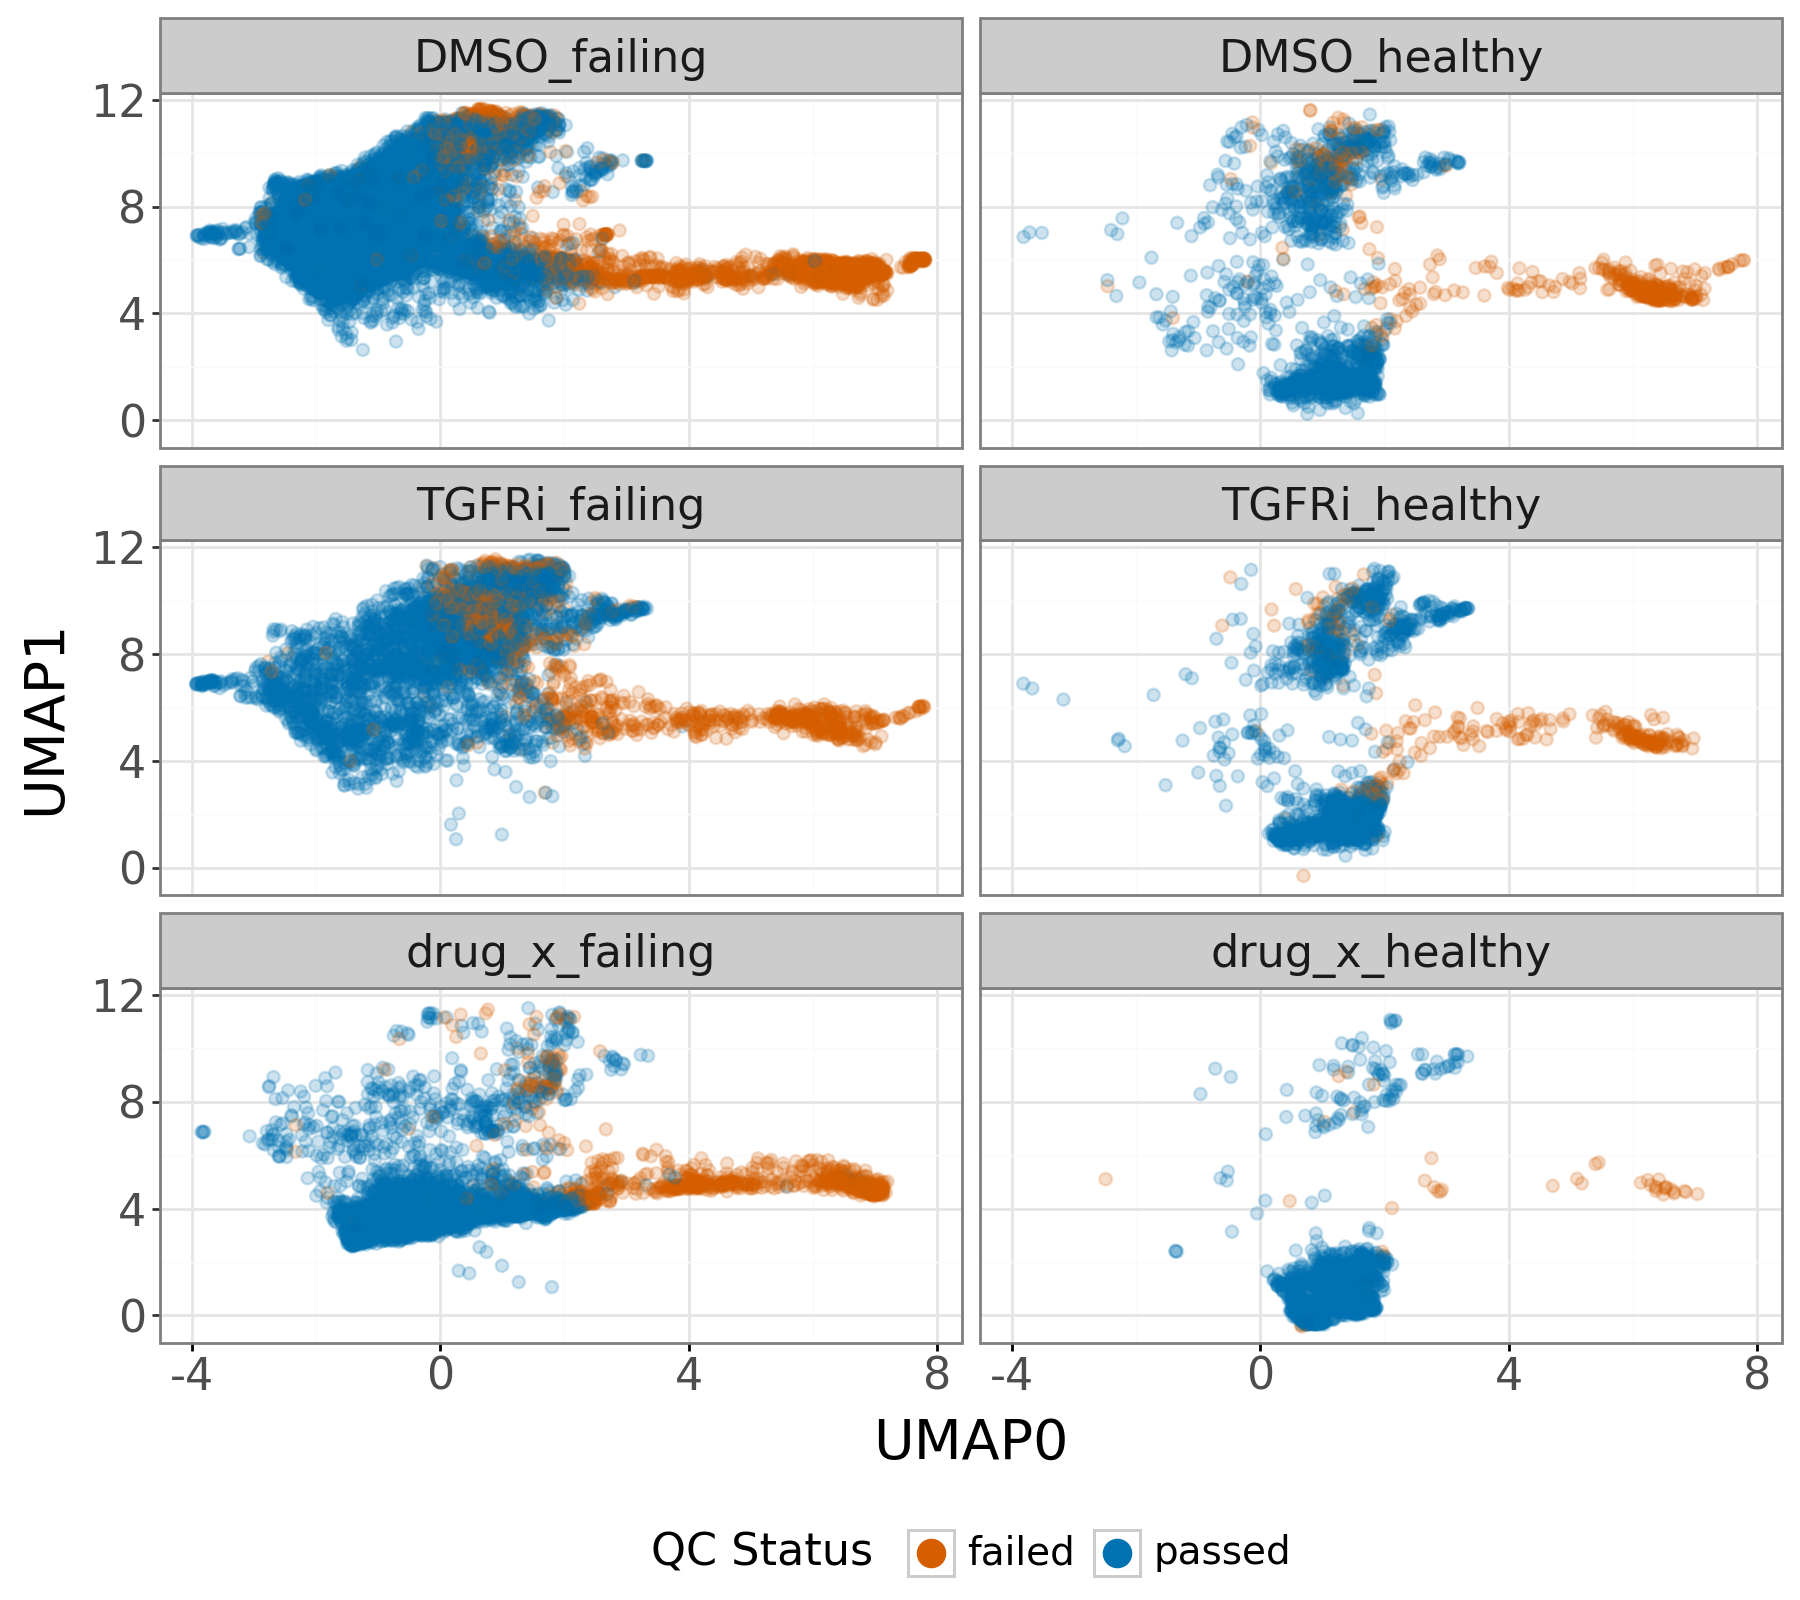

In [6]:
# Set the figure size
height = 8
width = 9
set_option("figure_size", (width, height))

# Plot UMAP of non-QC profiles labelled with QC status and
# faceted by treatment and cell type
p = (
    ggplot(
        cp_umap_with_metadata_df,
        aes(x="UMAP0", y="UMAP1", color="QC_status"),
    )
    + labs(
        color="QC Status",
    )
    + geom_point(alpha=0.2, size=2)
    + facet_wrap(
        "Metadata_Treatment_CellType_ID",
        ncol=2,
        scales="fixed",
    )
    + theme_bw()
    + theme(
        axis_title=element_text(size=20),
        axis_text=element_text(size=16),
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        legend_position="bottom",
        strip_text=element_text(size=16),  # Adjust facet label size
    )
    + scale_color_manual(
        values={"passed": "#0072B2", "failed": "#D55E00"}
    )  # Blue for passed, orange for failed (colorblind-friendly)
    + guides(
        color=guide_legend(
            override_aes={
                "alpha": 1,  # fully opaque in legend
                "size": 5,  # bigger points in legend
            }
        )
    )
)
# Save the plot
p.save(output_dir / "facet_umap_no_QC_plot.png", dpi=600, width=width, height=height)

p.show()

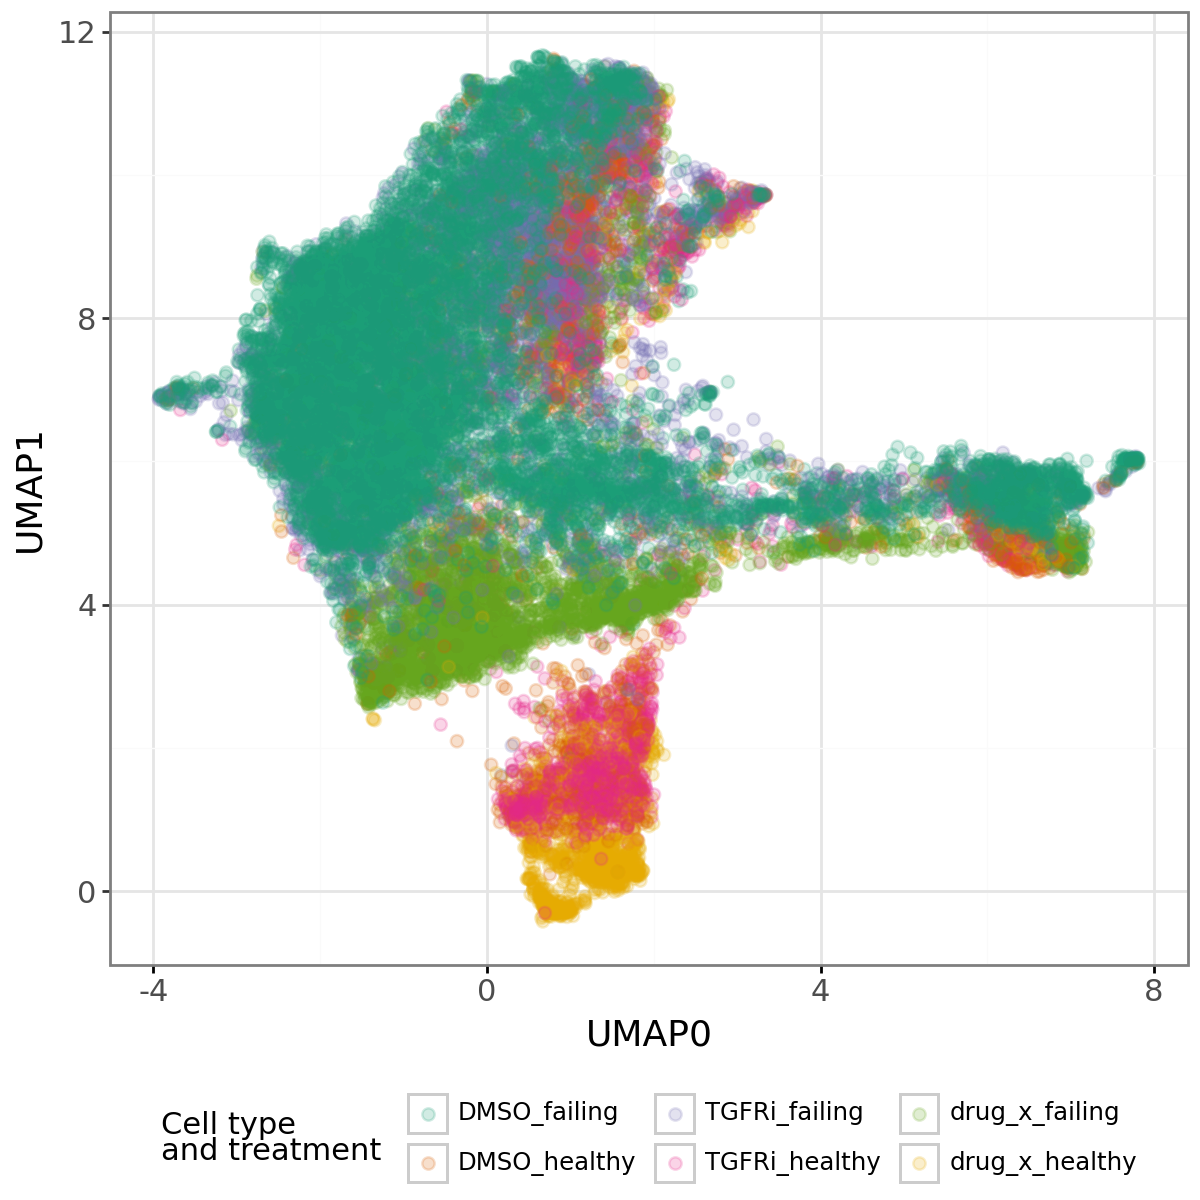

In [7]:
# Set the figure size
height = 6
width = 6
set_option("figure_size", (width, height))

# Plot with custom color palette
p = (
    ggplot(
        cp_umap_with_metadata_df,
        aes(x="UMAP0", y="UMAP1", color="Metadata_Treatment_CellType_ID"),
    )
    + labs(
        color="Cell type\nand treatment",
    )
    + geom_point(alpha=0.2, size=2)
    + theme_bw()
    + theme(
        axis_title=element_text(size=13),
        axis_text=element_text(size=11),
        plot_title=element_text(
            size=14,
        ),
        legend_position="bottom",
    )
    + scale_color_brewer(type="qual", palette="Dark2")  # Change palette as needed
)

p.show()